<a href="https://colab.research.google.com/github/ednavivianasegura/Curso_ML_Python/blob/main/Modulo2_Fundamentos_AI/SVM_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ednavivianasegura/ERAP_CursoPython.git

Cloning into 'ERAP_CursoPython'...
remote: Enumerating objects: 1145, done.
remote: Counting objects: 100% (260/260), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 1145 (delta 220), reused 93 (delta 92), pack-reused 885 (from 3)
Receiving objects: 100% (1145/1145), 69.79 MiB | 16.29 MiB/s, done.
Resolving deltas: 100% (616/616), done.
Updating files: 100% (169/169), done.


In [ ]:
import os
os.chdir("/content/ERAP_CursoPython/Modulo2_Fundamentos_AI")

In [ ]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# @title
%%html

<div align="center" style="
font-family:Arial;
margin-top:30px;
">

<!-- TÍTULO -->

<h1 style="
color:#111827;
font-size:58px;
font-weight:800;
margin-bottom:12px;
">
Máquinas de Soporte Vectorial (SVM)
</h1>

<div style="
width:92%;
height:4px;
background:#1E3A8A;
margin-bottom:45px;
border-radius:10px;
">
</div>

<!-- FUNDAMENTACIÓN -->

<div style="
display:flex;
align-items:flex-start;
justify-content:center;
gap:50px;
flex-wrap:wrap;
">

<!-- TEXTO -->

<div style="
width:38%;
text-align:left;
">

<div style="
display:flex;
align-items:center;
gap:12px;
margin-bottom:20px;
">

<div style="
width:42px;
height:42px;
background:#2563EB;
color:white;
border-radius:50%;
display:flex;
align-items:center;
justify-content:center;
font-size:22px;
font-weight:700;
">
1
</div>

<h2 style="
color:#111827;
font-size:40px;
margin:0;
font-weight:800;
">
Fundamentación
</h2>

</div>

<p style="
font-size:23px;
line-height:1.9;
color:#475569;
">

Las <strong>Máquinas de Soporte Vectorial (SVM)</strong>
son algoritmos supervisados utilizados para tareas de clasificación y regresión.

El objetivo principal consiste en encontrar un
<strong style="color:#0F766E;">hiperplano óptimo</strong>
capaz de separar las clases maximizando el margen entre ellas.

</p>

<p style="
font-size:22px;
line-height:1.8;
color:#64748B;
">

Los puntos más cercanos al hiperplano reciben el nombre de
<strong>vectores de soporte</strong>, y son fundamentales para definir la frontera de decisión.

</p>

</div>

<!-- PANEL DE GRÁFICOS -->

<div style="
display:grid;
grid-template-columns:repeat(2, 1fr);
gap:24px;
">

<!-- GRÁFICA 1 -->

<svg width="280" height="220"
style="
background:#F8FAFC;
border-radius:18px;
box-shadow:0px 4px 14px rgba(0,0,0,0.08);
">

<!-- GRID -->

<g opacity="0.15">

<line x1="40" y1="30" x2="40" y2="180" stroke="black"/>
<line x1="80" y1="30" x2="80" y2="180" stroke="black"/>
<line x1="120" y1="30" x2="120" y2="180" stroke="black"/>
<line x1="160" y1="30" x2="160" y2="180" stroke="black"/>
<line x1="200" y1="30" x2="200" y2="180" stroke="black"/>

<line x1="40" y1="30" x2="240" y2="30" stroke="black"/>
<line x1="40" y1="70" x2="240" y2="70" stroke="black"/>
<line x1="40" y1="110" x2="240" y2="110" stroke="black"/>
<line x1="40" y1="150" x2="240" y2="150" stroke="black"/>

</g>

<!-- HYPERPLANE -->

<line x1="110" y1="170" x2="190" y2="40"
stroke="#EC4899"
stroke-width="4"/>

<!-- BLACK -->

<circle cx="70" cy="60" r="4" fill="#111827"/>
<circle cx="90" cy="90" r="4" fill="#111827"/>
<circle cx="110" cy="120" r="4" fill="#111827"/>
<circle cx="80" cy="140" r="4" fill="#111827"/>
<circle cx="120" cy="70" r="4" fill="#111827"/>

<!-- BLUE -->

<circle cx="190" cy="80" r="4" fill="#2563EB"/>
<circle cx="200" cy="110" r="4" fill="#2563EB"/>
<circle cx="210" cy="140" r="4" fill="#2563EB"/>
<circle cx="180" cy="150" r="4" fill="#2563EB"/>
<circle cx="220" cy="100" r="4" fill="#2563EB"/>

</svg>

<!-- GRÁFICA 2 -->

<svg width="280" height="220"
style="
background:#F8FAFC;
border-radius:18px;
box-shadow:0px 4px 14px rgba(0,0,0,0.08);
">

<g opacity="0.15">

<line x1="40" y1="30" x2="40" y2="180" stroke="black"/>
<line x1="80" y1="30" x2="80" y2="180" stroke="black"/>
<line x1="120" y1="30" x2="120" y2="180" stroke="black"/>
<line x1="160" y1="30" x2="160" y2="180" stroke="black"/>
<line x1="200" y1="30" x2="200" y2="180" stroke="black"/>

<line x1="40" y1="30" x2="240" y2="30" stroke="black"/>
<line x1="40" y1="70" x2="240" y2="70" stroke="black"/>
<line x1="40" y1="110" x2="240" y2="110" stroke="black"/>
<line x1="40" y1="150" x2="240" y2="150" stroke="black"/>

</g>

<!-- BAD HYPERPLANE -->

<line x1="70" y1="160" x2="220" y2="100"
stroke="#EC4899"
stroke-width="4"/>

<!-- POINTS -->

<circle cx="70" cy="60" r="4" fill="#111827"/>
<circle cx="90" cy="90" r="4" fill="#111827"/>
<circle cx="110" cy="120" r="4" fill="#111827"/>
<circle cx="80" cy="140" r="4" fill="#111827"/>

<circle cx="190" cy="80" r="4" fill="#2563EB"/>
<circle cx="200" cy="110" r="4" fill="#2563EB"/>
<circle cx="210" cy="140" r="4" fill="#2563EB"/>
<circle cx="180" cy="150" r="4" fill="#2563EB"/>

</svg>

<!-- GRÁFICA 3 -->

<svg width="280" height="220"
style="
background:#F8FAFC;
border-radius:18px;
box-shadow:0px 4px 14px rgba(0,0,0,0.08);
">

<g opacity="0.15">

<line x1="40" y1="30" x2="40" y2="180" stroke="black"/>
<line x1="80" y1="30" x2="80" y2="180" stroke="black"/>
<line x1="120" y1="30" x2="120" y2="180" stroke="black"/>
<line x1="160" y1="30" x2="160" y2="180" stroke="black"/>
<line x1="200" y1="30" x2="200" y2="180" stroke="black"/>

<line x1="40" y1="30" x2="240" y2="30" stroke="black"/>
<line x1="40" y1="70" x2="240" y2="70" stroke="black"/>
<line x1="40" y1="110" x2="240" y2="110" stroke="black"/>
<line x1="40" y1="150" x2="240" y2="150" stroke="black"/>

</g>

<!-- BAD HYPERPLANE -->

<line x1="140" y1="170" x2="120" y2="40"
stroke="#EC4899"
stroke-width="4"/>

<!-- POINTS -->

<circle cx="70" cy="60" r="4" fill="#111827"/>
<circle cx="90" cy="90" r="4" fill="#111827"/>
<circle cx="110" cy="120" r="4" fill="#111827"/>
<circle cx="80" cy="140" r="4" fill="#111827"/>

<circle cx="190" cy="80" r="4" fill="#2563EB"/>
<circle cx="200" cy="110" r="4" fill="#2563EB"/>
<circle cx="210" cy="140" r="4" fill="#2563EB"/>
<circle cx="180" cy="150" r="4" fill="#2563EB"/>

</svg>

<!-- GRÁFICA 4 -->

<svg width="280" height="220"
style="
background:#F8FAFC;
border-radius:18px;
box-shadow:0px 4px 14px rgba(0,0,0,0.08);
">

<g opacity="0.15">

<line x1="40" y1="30" x2="40" y2="180" stroke="black"/>
<line x1="80" y1="30" x2="80" y2="180" stroke="black"/>
<line x1="120" y1="30" x2="120" y2="180" stroke="black"/>
<line x1="160" y1="30" x2="160" y2="180" stroke="black"/>
<line x1="200" y1="30" x2="200" y2="180" stroke="black"/>

<line x1="40" y1="30" x2="240" y2="30" stroke="black"/>
<line x1="40" y1="70" x2="240" y2="70" stroke="black"/>
<line x1="40" y1="110" x2="240" y2="110" stroke="black"/>
<line x1="40" y1="150" x2="240" y2="150" stroke="black"/>

</g>

<!-- OPTIMAL HYPERPLANE -->

<line x1="120" y1="170" x2="190" y2="40"
stroke="#EC4899"
stroke-width="5"/>

<!-- MARGINS -->

<line x1="100" y1="170" x2="170" y2="40"
stroke="#F9A8D4"
stroke-width="2"
stroke-dasharray="6 6"/>

<line x1="140" y1="170" x2="210" y2="40"
stroke="#F9A8D4"
stroke-width="2"
stroke-dasharray="6 6"/>

<!-- POINTS -->

<circle cx="70" cy="60" r="4" fill="#111827"/>
<circle cx="90" cy="90" r="4" fill="#111827"/>
<circle cx="110" cy="120" r="4" fill="#111827"/>
<circle cx="80" cy="140" r="4" fill="#111827"/>

<circle cx="190" cy="80" r="4" fill="#2563EB"/>
<circle cx="200" cy="110" r="4" fill="#2563EB"/>
<circle cx="210" cy="140" r="4" fill="#2563EB"/>
<circle cx="180" cy="150" r="4" fill="#2563EB"/>

</svg>

</div>

</div>

<!-- CONCLUSIÓN -->

<div align="center" style="
margin-top:60px;
padding:35px;
width:82%;
margin-left:auto;
margin-right:auto;
background:linear-gradient(135deg,#F8FAFC,#F1F5F9);
border-radius:24px;
box-shadow:0px 4px 16px rgba(0,0,0,0.08);
">

<h2 style="
color:#1E3A8A;
font-size:38px;
font-family:Arial;
font-weight:800;
margin-bottom:20px;
">
🎯 Idea Clave
</h2>

<p style="
color:#475569;
font-size:22px;
font-family:Arial;
line-height:1.9;
">

El objetivo de SVM consiste en encontrar el hiperplano que maximiza
la separación entre clases, mejorando la capacidad de generalización
del modelo sobre nuevos datos.

</p>

</div>

</div>

In [35]:
%%html

<div align="center" style="
font-family:Arial;
margin-top:35px;
">

<!-- TÍTULO -->

<h1 style="
color:#1E3A8A;
font-size:56px;
font-weight:800;
margin-bottom:12px;
">
🧠 Support Vector Machine
</h1>

<p style="
color:#475569;
font-size:24px;
margin-bottom:35px;
">
Separación óptima entre clases mediante hiperplanos de máximo margen
</p>

<!-- PANEL -->

<svg width="900" height="620"
style="
background:linear-gradient(135deg,#F8FAFC,#EEF2FF);
border-radius:28px;
box-shadow:0px 6px 22px rgba(0,0,0,0.10);
">

<!-- GRID -->

<g opacity="0.08">

<!-- Vertical -->
<line x1="120" y1="70" x2="120" y2="520" stroke="#334155"/>
<line x1="190" y1="70" x2="190" y2="520" stroke="#334155"/>
<line x1="260" y1="70" x2="260" y2="520" stroke="#334155"/>
<line x1="330" y1="70" x2="330" y2="520" stroke="#334155"/>
<line x1="400" y1="70" x2="400" y2="520" stroke="#334155"/>
<line x1="470" y1="70" x2="470" y2="520" stroke="#334155"/>
<line x1="540" y1="70" x2="540" y2="520" stroke="#334155"/>
<line x1="610" y1="70" x2="610" y2="520" stroke="#334155"/>
<line x1="680" y1="70" x2="680" y2="520" stroke="#334155"/>

<!-- Horizontal -->
<line x1="80" y1="120" x2="760" y2="120" stroke="#334155"/>
<line x1="80" y1="190" x2="760" y2="190" stroke="#334155"/>
<line x1="80" y1="260" x2="760" y2="260" stroke="#334155"/>
<line x1="80" y1="330" x2="760" y2="330" stroke="#334155"/>
<line x1="80" y1="400" x2="760" y2="400" stroke="#334155"/>
<line x1="80" y1="470" x2="760" y2="470" stroke="#334155"/>

</g>

<!-- AXES -->

<line x1="90" y1="520" x2="780" y2="520"
stroke="#111827"
stroke-width="10"/>

<line x1="90" y1="60" x2="90" y2="520"
stroke="#111827"
stroke-width="10"/>

<!-- AXIS LABELS -->

<text x="430" y="595"
font-size="58"
font-family="Arial"
font-weight="800"
fill="#111827">
X
</text>

<text x="20" y="300"
font-size="58"
font-family="Arial"
font-weight="800"
fill="#111827">
Y
</text>

<!-- MARGIN LINES -->

<line x1="210" y1="180" x2="650" y2="500"
stroke="#64748B"
stroke-width="3"
stroke-dasharray="10 10"
opacity="0.7"/>

<line x1="210" y1="80" x2="650" y2="400"
stroke="#64748B"
stroke-width="3"
stroke-dasharray="10 10"
opacity="0.7"/>

<!-- MAIN HYPERPLANE -->

<line x1="210" y1="130" x2="650" y2="450"
stroke="#111827"
stroke-width="5"
stroke-linecap="round">

<animate attributeName="stroke-dasharray"
from="0,1200"
to="1200,0"
dur="2.2s"
fill="freeze"/>

</line>

<!-- GREEN CLASS -->

<circle cx="240" cy="420" r="14" fill="#4ADE80"/>
<circle cx="280" cy="470" r="14" fill="#4ADE80"/>
<circle cx="320" cy="430" r="14" fill="#4ADE80"/>
<circle cx="370" cy="420" r="14" fill="#4ADE80"/>
<circle cx="300" cy="390" r="14" fill="#4ADE80"/>

<!-- BLUE CLASS -->

<circle cx="540" cy="150" r="14" fill="#2563EB"/>
<circle cx="610" cy="130" r="14" fill="#2563EB"/>
<circle cx="610" cy="200" r="14" fill="#2563EB"/>
<circle cx="550" cy="220" r="14" fill="#2563EB"/>
<circle cx="590" cy="270" r="14" fill="#2563EB"/>

<!-- SUPPORT VECTORS -->

<circle cx="460" cy="210" r="16"
fill="#D946EF"
stroke="white"
stroke-width="4">

<animate attributeName="r"
values="0;18;16"
dur="1.4s"
fill="freeze"/>

</circle>

<circle cx="350" cy="410" r="16"
fill="#D946EF"
stroke="white"
stroke-width="4">

<animate attributeName="r"
values="0;18;16"
dur="1.8s"
fill="freeze"/>

</circle>

<!-- LABELS -->

<text x="385" y="255"
font-size="24"
font-family="Arial"
font-weight="700"
fill="#334155">
Vector de soporte
</text>

<text x="260" y="360"
font-size="24"
font-family="Arial"
font-weight="700"
fill="#334155">
Vector de soporte
</text>

<!-- ARROWS -->

<line x1="430" y1="235" x2="455" y2="215"
stroke="#334155"
stroke-width="3"/>

<line x1="335" y1="370" x2="350" y2="400"
stroke="#334155"
stroke-width="3"/>

<!-- MARGIN BRACKET -->

<line x1="550" y1="430" x2="600" y2="370"
stroke="#2563EB"
stroke-width="3"/>

<line x1="580" y1="400" x2="700" y2="390"
stroke="#2563EB"
stroke-width="3"/>

<line x1="580" y1="400" x2="590" y2="390"
stroke="#2563EB"
stroke-width="3"/>

<line x1="580" y1="400" x2="590" y2="410"
stroke="#2563EB"
stroke-width="3"/>

<text x="705" y="395"
font-size="24"
font-family="Arial"
font-weight="700"
fill="#2563EB">
Margen Máximo
</text>

<!-- LEGEND -->

<div></div>

</svg>

<!-- EXPLANATION -->

<div style="
margin-top:35px;
width:82%;
font-size:22px;
line-height:1.9;
color:#475569;
">

El hiperplano óptimo maximiza la distancia entre clases.
Los vectores de soporte son las observaciones más cercanas a la frontera de decisión
y determinan la posición del modelo.

</div>

</div>

In [43]:
%%html

<style>

body{
  background:#e9e9e9;
  font-family:Arial, sans-serif;
}

.container{
  width:700px;
  height:520px;
  margin:auto;
  position:relative;
  background:#efefef;
}

/* Título */
.title{
  position:absolute;
  top:10px;
  left:90px;
  font-size:32px;
  font-weight:bold;
  color:#333;
}

/* Ejes */
.x-axis{
  position:absolute;
  bottom:40px;
  left:60px;
  width:560px;
  height:10px;
  background:black;
}

.y-axis{
  position:absolute;
  bottom:40px;
  left:60px;
  width:10px;
  height:430px;
  background:black;
}

/* Letras de ejes */
.x-label{
  position:absolute;
  bottom:-5px;
  left:350px;
  font-size:56px;
  color:#222;
}

.y-label{
  position:absolute;
  left:15px;
  top:220px;
  font-size:56px;
  color:#222;
}

/* Banda del margen */
.margin{
  position:absolute;
  width:370px;
  height:180px;
  background:rgba(115, 231, 236, 0.55);
  border-left:4px dashed #555;
  border-right:4px dashed #555;
  transform:rotate(45deg);
  top:150px;
  left:145px;
}

/* Línea central */
.separator{
  position:absolute;
  width:4px;
  height:360px;
  background:#222;
  top:-40px;
  left:180px;
  transform:rotate(90deg);
}

/* Puntos */
.point{
  position:absolute;
  width:28px;
  height:28px;
  border-radius:50%;
}

/* Azules */
.blue{
  background:#2d56c0;
}

/* Verdes */
.green{
  background:#48e638;
}

/* Punto celeste */
.lightblue{
  background:#56bff0;
}

/* Texto margen */
.margin-text{
  position:absolute;
  right:10px;
  top:240px;
  color:#555;
  font-size:22px;
  font-weight:bold;
}

.margin-text small{
  font-weight:normal;
}

</style>

<div class="container">

  <div class="title">
    El parámetro C, controla el margen
  </div>

  <!-- Ejes -->
  <div class="x-axis"></div>
  <div class="y-axis"></div>

  <!-- Etiquetas -->
  <div class="x-label">X</div>
  <div class="y-label">Y</div>

  <!-- Margen -->
  <div class="margin">
    <div class="separator"></div>
  </div>

  <!-- Puntos verdes -->
  <div class="point green" style="left:150px; top:330px;"></div>
  <div class="point green" style="left:190px; top:330px;"></div>
  <div class="point green" style="left:170px; top:380px;"></div>
  <div class="point green" style="left:220px; top:380px;"></div>
  <div class="point green" style="left:130px; top:380px;"></div>
  <div class="point green" style="left:150px; top:425px;"></div>

  <!-- Punto azul claro -->
  <div class="point lightblue" style="left:300px; top:300px;"></div>

  <!-- Puntos azules -->
  <div class="point blue" style="left:320px; top:210px;"></div>
  <div class="point blue" style="left:380px; top:170px;"></div>
  <div class="point blue" style="left:440px; top:150px;"></div>
  <div class="point blue" style="left:450px; top:200px;"></div>
  <div class="point blue" style="left:390px; top:220px;"></div>
  <div class="point blue" style="left:420px; top:270px;"></div>

  <!-- Texto -->
  <div class="margin-text">
    margen blando<br>
    <small>o "soft margin"</small>
  </div>

</div>

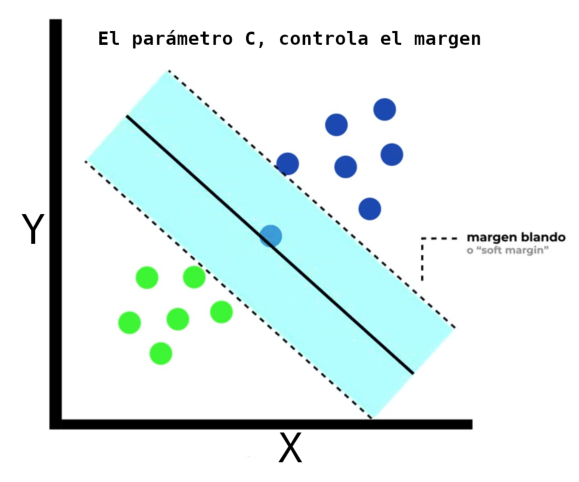

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.figure(figsize=(10, 6))
img = mpimg.imread('Imagenes/SVM_C_MargenBlando.png')
plt.imshow(img)
plt.axis('off')  # Opcional: oculta los ejes
plt.show()

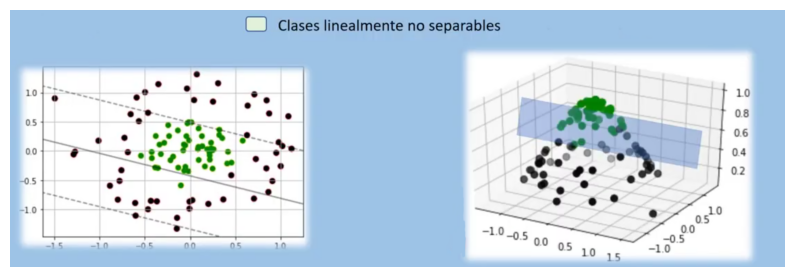

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.figure(figsize=(10, 6))
img = mpimg.imread('Imagenes/SVM_C_Kernel.png')
plt.imshow(img)
plt.axis('off')  # Opcional: oculta los ejes
plt.show()

In [ ]:
# 1. Cargar el dataset y convertirlo en DataFrame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Separar X (características) e y (etiqueta) usando .drop()
X = df.drop('target', axis=1)
y = df['target']
# df['target'] = df['target'].map({0: 'malignant', 1: 'benign'})  # etiquetas legibles

In [ ]:
# Configurar el estilo de Seaborn
sns.set(style="whitegrid")

# Crear un pairplot y guardarlo en una variable
pairplot = sns.pairplot(df[['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness','target']], hue='target')

In [ ]:
# 2. Visualización exploratoria con seaborn
plt.figure(figsize=(8, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribución de clases')
plt.show()

In [ ]:
# 3. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# 4. Escalar características (muy importante para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 5. Entrenar el modelo SVM con kernel lineal
svm = SVC(kernel='linear', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)

In [ ]:
# 6. Predicciones
y_pred = svm.predict(X_test_scaled)

In [ ]:
# 7. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - SVM Lineal')
plt.show()

In [ ]:
# 8. Reporte de clasificación
print("Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

# 1. Generar datos artificiales no linealmente separables
X, y = make_circles(n_samples=300, factor=0.3, noise=0.1, random_state=42)

# Escalar los datos (importante para SVM con kernel RBF)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Se grafican los datos
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor='k')

In [ ]:
# Se divide en train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# 2. Entrenar SVM con kernel LINEAL
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

In [ ]:
# Se define una función para calcular la matriz de confusión y mostrar las métricas
def evaluar_modelo(y_test, y_pred, titulo):
    print(f"\n🔍 Evaluación del modelo: {titulo}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de confusión: {titulo}")
    plt.show()

In [ ]:
# Se define una función para calcular la matriz de confusión y mostrar las métricas
def graficar_frontera(modelo, X, y, titulo):
    h = 0.02  # paso del mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel1, alpha=0.8)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor='k')
    plt.title(titulo)
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.grid(True)
    plt.show()

In [ ]:
graficar_frontera(svm_linear, X_scaled, y, "Frontera de decisión - Kernel Lineal")

In [ ]:
evaluar_modelo(y_test, y_pred_linear, "SVM con Kernel Lineal")

**Esto significa que el modelo SVM con kernel lineal, está clasificando todos los datos como clase 0, y ninguno como clase 1.**

In [ ]:
## Ahora con un kernel de una función de base radial.

In [ ]:
# 3. Entrenar SVM con kernel RBF
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

In [ ]:
evaluar_modelo(y_test, y_pred_rbf, "SVM con Kernel RBF")

In [ ]:
graficar_frontera(svm_rbf, X_scaled, y, "Frontera de decisión - Kernel RBF")

In [ ]:
# Se grafican los datos
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor='k')

In [ ]:
nuevo_dato = np.array([[-0.5, 0]])

In [ ]:
nuevo_dato_escalado = scaler.transform(nuevo_dato)

In [ ]:
prediccion = svm_rbf.predict(nuevo_dato_escalado)
print("Clase predicha:", prediccion[0])